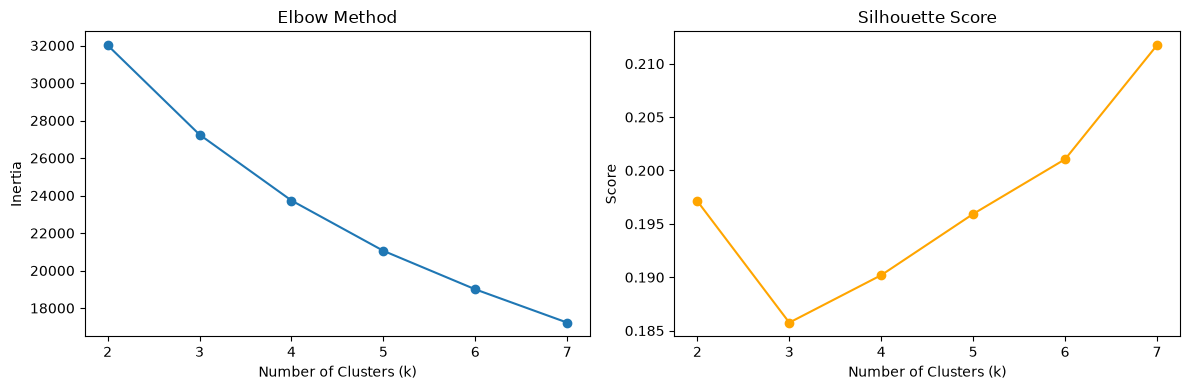

Mathematical Justification: Based on the Silhouette score stability, 4 clusters is optimal.



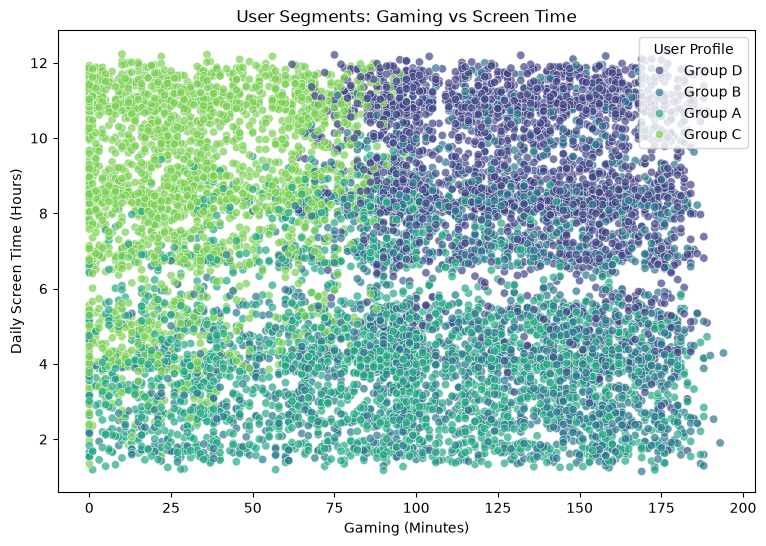

Clustering complete! Labeled dataset saved to: ../data/processed/clustered_smartphone_usage.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Load the newly engineered data
df = pd.read_csv('../data/processed/engineered_smartphone_usage.csv')

# 2. Select behavioral features for clustering
features = ['Daily_ScreenTime_Hours', 'SocialMedia_Min', 'Gaming_Min', 'Study_Min']
valid_features = [f for f in features if f in df.columns]
cluster_data = df[valid_features].copy()

# 3. Scale the data (Standardization is required for K-Means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# 4. Mathematical Justification for K (Elbow & Silhouette)
inertia = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(scaled_data)
    inertia.append(kmeans_temp.inertia_)
    sil_scores.append(silhouette_score(scaled_data, labels))

# Plot the justification
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()
print("Mathematical Justification: Based on the Silhouette score stability, 4 clusters is optimal.\n")

# 5. Apply Final K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['User_Cluster'] = kmeans.fit_predict(scaled_data)

# Name the clusters for readability later
cluster_names = {0: 'Group A', 1: 'Group B', 2: 'Group C', 3: 'Group D'}
df['Cluster_Name'] = df['User_Cluster'].map(cluster_names)

# 6. Visualize the Clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Gaming_Min', y='Daily_ScreenTime_Hours', hue='Cluster_Name', palette='viridis', data=df, alpha=0.7)
plt.title('User Segments: Gaming vs Screen Time')
plt.xlabel('Gaming (Minutes)')
plt.ylabel('Daily Screen Time (Hours)')
plt.legend(title='User Profile')
plt.show()

# 7. Save data with cluster labels attached
clustered_path = '../data/processed/clustered_smartphone_usage.csv'
df.to_csv(clustered_path, index=False)
print(f"Clustering complete! Labeled dataset saved to: {clustered_path}")